# Public profile axis

The competitive axis measures how good a fighter is; this notebook builds the public profile axis, which is how much of a draw they are. The two are meant to be read together, as the two halves of the value map.

This notebook:

*   Defines the active fighter universe the axis is built on
*   Resolves each fighter to a Wikipedia article, and confirms the genuine no-article cases
*   Pulls daily pageviews and splits them into a baseline (sustained profile) and an activation (the lift around a fight)
*   Measures news attention via GDELT news-mention volume
*   Combines the signals into a single public profile score by z-scoring across the active roster

Commercial value cannoy be observed directly, so it is treated as a latent variable inferred from attention signals rather than read off any financial figure. News coverage is counted by volume regardless of whether it is positive or negative, because a heel draws attention the same as a hero does.

Inputs come from the competitive axis ratings (`glicko_current_continuous.parquet`) and the round-level fight data. Outputs land in the same `Code Outputs` directory as the rest of the project.

## Section 1: Defining the scored universe

Before any data gets pulled, the active population needs to be defined. Rate limits are real in this section, so the external endpoints like GDELT are queried only for a curated set, not the full roster.

The scope is the active fighter base, not the full historical population. This keeps the data pulls manageable. "Active" gets an operational definition in the next section, derived from the distribution of months since each fighter's last fight; this comes once the population is decided.

Settling the population first means choosing which of the existing fighter lists to build on. Earlier steps produced a few (the full Glicko ratings, the round-level data, the GMM style set), and their counts differ slightly because each was built for a different purpose. This section lines them up, picks the one that works as the base, and that base is what the active fighter cut in the next task then filters on by last-fight date.

Matching is keyed on the `FIGHTER` column. The name is unique across the base, so within this pipeline it behaves as a stable key, and it's also the form the external attention signals get queried on later (Wikipedia titles, and the GDELT name match).

In [ ]:
# BLOCK 1: library imports and data location

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import requests, time
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import re
import unicodedata

# data location (portable across Drive and a local repo checkout)
try:
    from google.colab import drive
    drive.mount('/content/drive')
except (ImportError, ModuleNotFoundError):
    pass  # not in Colab

DRIVE_DIR = Path('/content/drive/MyDrive/Masters in Artificial Intelligence Applied to Sport/'
                 'Masters Final Project/Pugnator mapper valorem/EDA/Code Outputs')
OUTPUT_DIR = DRIVE_DIR if DRIVE_DIR.exists() else Path('./data')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Using data directory: {OUTPUT_DIR}')

Mounted at /content/drive


In [ ]:
# BLOCK 2: load the populations

rated_all   = pd.read_parquet(OUTPUT_DIR / 'glicko_current_continuous.parquet')  # base; has LAST_FIGHT
round_level = pd.read_parquet(OUTPUT_DIR / 'fight_stats_numeric.parquet')         # round-level stats
style       = pd.read_parquet(OUTPUT_DIR / 'style_clusters.parquet')             # GMM pop, 2 fight floor

In [ ]:
# BLOCK 3: reconcile populations
# keyed on FIGHTER

KEY = 'FIGHTER'

pops = {
    'rated_all':   set(rated_all[KEY]),
    'round_level': set(round_level[KEY]),
    'rated_2plus': set(rated_all.loc[rated_all['N_FIGHTS'] >= 2, KEY]),
    'style':       set(style[KEY]),
}

recon = pd.Series({k: len(v) for k, v in pops.items()}, name='N').sort_values(ascending=False)
print(recon.to_frame())

# flag anything in b but not a
labels = list(recon.index)
for a, b in zip(labels, labels[1:]):
    leak = len(pops[b] - pops[a])
    print(f'{a} ({len(pops[a])}) -> {b} ({len(pops[b])}): in {b} not {a} = {leak}')

                N
rated_all    2710
round_level  2698
rated_2plus  2289
style        2196
rated_all (2710) -> round_level (2698): in round_level not rated_all = 5
round_level (2698) -> rated_2plus (2289): in rated_2plus not round_level = 1
rated_2plus (2289) -> style (2196): in style not rated_2plus = 0


In [ ]:
# BLOCK 4: set the base population

base = rated_all.copy()   # superset; only table with LAST_FIGHT
print(f'base population: {len(base)} fighters')

base population: 2710 fighters


The fighter counts resolve cleanly because the groups nest inside one another, different slices of the same data rather than conflicting totals. `rated_all` (2,710) is every fighter with at least one modelable bout; the two-fight minimum cuts it to 2,281; the GMM style group sits at 2,196, the 85-fighter drop being fighters who meet the fight minimum but lack the round-by-round data a style read needs.

`rated_all` is the base for the public profile axis for three reasons: it is the largest, so nobody is dropped early; it is the only table carrying `LAST_FIGHT`, which the active filter needs; and it holds the competitive rating that places each fighter on the final plot. Four fighters (Mark Robinson, Pedro Nobre, Robert Drysdale, Ron Faircloth) have round-level data but no Glicko rating, and are excluded, since without a competitive score they cannot be plotted anyway.

The join key is the `FIGHTER` name, not a hash id. The name is unique across the rated base, so it links reliably within the project, and it is also the form the external sources are queried on (Wikipedia, and the GDELT name match). The one risk, two fighters sharing a name, only surfaces when external search data is merged, and is handled there.

## Section 2: Active fighter filter

With the base settled at 2,710, this section cuts it down to the fighters who are actually active, since they are who the dashboard is built around and who the per-fighter signal pulls are worth spending on. Everything here keys off `LAST_FIGHT`.

"Active" needs an operational definition, and the one thing it should not be is a round number picked because it sounds about right. The cleaner approach, and the one already used for the Glicko warm-up tiers, is to let the data set the threshold: look at the distribution of time since each fighter's last bout and find where a normal gap between fights stops looking like a gap and starts looking like someone who has drifted out of the sport. MMA cadence is a couple of bouts a year, with injury, suspension and contract limbo stretching that even for fighters who are unambiguously still around, so the cut should sit above that noise rather than through it.

The definition is purely about recency. A fighter who has not competed in a long time falls outside the active base no matter how well known they are, because this axis is about the current active roster, not the residual fame of fighters who have stopped competing. That is a deliberate scope choice, and the under-representation it creates is something to record for the limitations rather than patch over here.

The threshold is a calibration value, not a structural one, so it can move later on evidence as long as the reasoning is logged. The output of the task is an active fighter list that every signal step pulls against.

ANALYSIS_DATE (freeze): 2026-07-11
  <= 12 months:  623 fighters
  <= 18 months:  712 fighters
  <= 24 months:  791 fighters
  <= 30 months:  845 fighters
  <= 36 months:  889 fighters
  <= 48 months: 1003 fighters


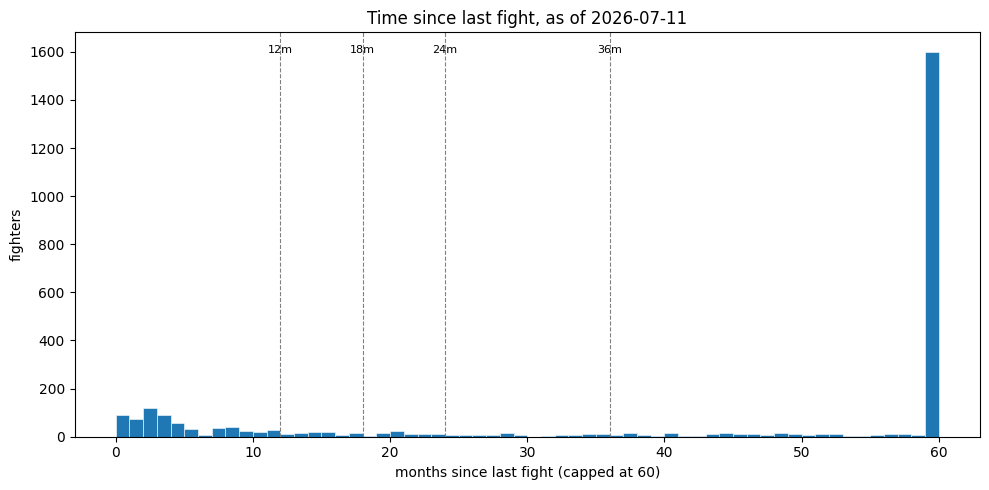

In [ ]:
# BLOCK 5: locate the active fighter cut

# analysis date pinned to the data freeze (UFC 329, 11 July 2026)

ANALYSIS_DATE = pd.Timestamp('2026-07-11')
print(f'ANALYSIS_DATE (freeze): {ANALYSIS_DATE.date()}')

base = base.copy()
base['LAST_FIGHT'] = pd.to_datetime(base['LAST_FIGHT'], errors='coerce')

# warn if data moved past the frozen date
latest_fight = base['LAST_FIGHT'].max()
if latest_fight > ANALYSIS_DATE + pd.Timedelta(days=30):
    print(f'NOTE: newest LAST_FIGHT is {latest_fight.date()} but ANALYSIS_DATE is '
          f'{ANALYSIS_DATE.date()}; advance ANALYSIS_DATE if this is a refreshed run')

months = ((ANALYSIS_DATE - base['LAST_FIGHT']).dt.days / 30.44).dropna()   # 30.44 = mean days/month

# survivors at each candidate window
for w in (12, 18, 24, 30, 36, 48):
    print(f'  <= {w:>2} months: {(months <= w).sum():>4} fighters')

# cap at 60; retired tail drowns the live cluster otherwise
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(months.clip(upper=60), bins=60, edgecolor='white', linewidth=0.4)
for m in (12, 18, 24, 36):
    ax.axvline(m, color='grey', linestyle='--', linewidth=0.8)
    ax.text(m, ax.get_ylim()[1]*0.95, f'{m}m', fontsize=8, ha='center')
ax.set_xlabel('months since last fight (capped at 60)')
ax.set_ylabel('fighters')
ax.set_title(f'Time since last fight, as of {ANALYSIS_DATE.date()}')
plt.tight_layout()
plt.show()

In [ ]:
# BLOCK 6: apply the cut and freeze

CUT_MONTHS = 24   # from 2a

months_since = (ANALYSIS_DATE - base['LAST_FIGHT']).dt.days / 30.44

# NaN dates fail the <=,
active = base.loc[months_since <= CUT_MONTHS].copy()

print(f'cut: <= {CUT_MONTHS} months since last fight (as of {ANALYSIS_DATE.date()})')
print(f'active universe: {len(active)} of {len(base)} fighters '
      f'({len(active) / len(base) * 100:.1f}% of the rated base)')

# freeze output
out_path = OUTPUT_DIR / 'active_universe.parquet'
active.to_parquet(out_path, index=False)
print(f'saved as: {out_path.name}')

cut: <= 24 months since last fight (as of 2026-07-11)
active universe: 791 of 2710 fighters (29.2% of the rated base)
saved as: active_universe.parquet


The distribution of months since last fight shows a large retired tail that has to be trimmed; the active fighters are a minority cluster near the origin, swamped by everyone who ever fought. The cut is set at 24 months, and the distribution nominates it: the intake rate holds at roughly 85 to 90 fighters per six-month step up to 24 months, then halves, which marks where the dense active cluster gives way to the sparse semi-retired region. It also sits above the normal injury and layoff gaps that a tighter window would slice through, dropping fighters who are genuinely still active but had a quiet year.

The cut leaves 791 fighters in the active universe, 28.8% of the rated base. That sits a little above the UFC's contracted roster, which is the expected shape, since the window also catches recently departed and long-injured fighters who have not formally been cut. The remaining 70.8% are the historical population this axis is deliberately not about; the public profile axis describes the current active roster, and a fighter's residual fame after they stop competing is out of scope by design.

The 24 month value is a calibration decision, not a structural one, so it can move later on evidence provided the change is logged.

## Section 3: Wikipedia pageviews

Pageviews are the first attention signal. Wikimedia's API returns absolute daily counts per article from mid-2015; one call per fighter gives a directly comparable number. This is where the windowing the rest of the notebook reuses is settled: the split between a continuous baseline (sustained interest) and a fight-window activation (the spike around a bout).

Resolution is where the work lies in this section. The API keys on the exact article title, and fighter titles are messy: some use a plain name, some carry a "(fighter)" or "(mixed martial artist)" suffix, some redirect, and some fighters have no article at all. Mapping names to the right article, and deciding what a fighter with no article means, is handled in the next task.

Note: daily pageview data starts in mid-2015, so the baseline window has less depth for long-tenured fighters than the competitive axis does. For an active roster that has mostly fought recently this is minor, but it remains a potential limitation in some cases.

### Resolving names to article titles

A sampled check of forty names found roughly four resolving to the wrong thing: a namesake article, a more famous non-fighter, or a real fighter whose entry was too thin to verify. Scaled across the roster that is a meaningful number of fighters picking up a stranger's pageviews, and it is a silent error, since a wrong match returns a plausible figure rather than a blank. So resolution verifies each match, sorting each fighter into one of three outcomes: a confident auto-match, a confirmed true zero (no English article exists), or needs review, where Human in the Loop (HITL) comes into play.

A match counts as confident only if the article checks out as a fighter, by either its Wikipedia categories or its Wikidata occupation, since the two miss in opposite directions. A lower profile fighter can often be in the MMA categories but have a bare Wikidata entry, so the category check catches them where an occupation check alone would reject them.

A found article that fails verification never becomes a zero automatically; it goes to review. A genuine no article fighter is a real low profile signal and a legitimate zero, but a wrong match recorded as a zero is a false reading, so the two are kept apart by sending every ambiguous case for a HITL check.

Manual decisions live in the override and known-zero tables, checked before the automated path so they always win. The resolved map is saved, so this is a one time pass; later runs skip everything already settled and work only names not seen before.

In [ ]:
# BLOCK 7: manual resolution overrides

# real article found at a non-obvious title
TITLE_OVERRIDES = {
    'Natalia Silva': 'Natália Silva (fighter)',
    'Chris Duncan':  'Chris Duncan (fighter)',
    'Sam Hughes':    'Sam Hughes (fighter)',
    'Mizuki':        'Mizuki Inoue',
    'Diana Belbita': 'Diana Belbita',
}

# confirmed no English article
KNOWN_ZEROS = {
    'Seokhyeon Ko', 'Jose Delgado', 'Juan Diaz', 'SuYoung You', 'Victor Hugo',
    'Francis Marshall', 'ChangHo Lee', 'Xiao Long', 'Montse Rendon',
    'JeongYeong Lee', 'Quang Le', 'Yizha', 'Terrance Saeteurn',
    'Ben Johnston', 'Kevin Christian', 'Mohammad Yahya',
}

In [ ]:
# BLOCK 8: Wikipedia title resolver

# exact title first; search fallback for misses and namesakes. verify by MMA
# category OR wikidata occupation (either confirms).

sess = requests.Session()
sess.headers['User-Agent'] = 'MScResearch/1.0 (academic project; contact via GitHub)'
sess.mount('https://', HTTPAdapter(max_retries=Retry(
    total=5, backoff_factor=1.5, status_forcelist=[429, 500, 502, 503, 504])))

WP_API   = 'https://en.wikipedia.org/w/api.php'
WD_API   = 'https://www.wikidata.org/w/api.php'
MMA_QID  = 'Q11607585'                                    # 'mixed martial arts fighter'
CAT_HITS = ('mixed martial art', 'ultimate fighting championship')  # category substrings

def _get(url, params):
    # parsed json or None; never throw on a bad/non-json response
    try:
        r = sess.get(url, params=params, timeout=20)
        if r.status_code != 200 or 'json' not in r.headers.get('Content-Type', ''):
            return None
        return r.json()
    except Exception:
        return None

def lookup(title):
    # exact title + redirect. returns (resolved_title|None, qid|None, {category titles})
    d = _get(WP_API, {'action': 'query', 'titles': title, 'redirects': 1,
                      'prop': 'categories|pageprops', 'ppprop': 'wikibase_item',
                      'cllimit': 500, 'format': 'json'})
    if not d:
        return None, None, set()
    page = next(iter(d['query']['pages'].values()))
    if 'missing' in page:
        return None, None, set()
    cats = {c['title'].lower() for c in page.get('categories', [])}
    return page['title'], page.get('pageprops', {}).get('wikibase_item'), cats

def search_titles(name, n=5):
    # fuzzy search; tolerates accents, surfaces '(fighter)' titles. mainspace only.
    d = _get(WP_API, {'action': 'query', 'list': 'search', 'srsearch': name,
                      'srlimit': n, 'format': 'json'})
    if not d:
        return []
    return [r['title'] for r in d['query']['search'] if ':' not in r['title']]

def _wd_is_fighter(qid):
    d = _get(WD_API, {'action': 'wbgetclaims', 'entity': qid,
                      'property': 'P106', 'format': 'json'})
    if not d:
        return False
    claims = d.get('claims', {}).get('P106', [])
    return any(c['mainsnak'].get('datavalue', {}).get('value', {}).get('id') == MMA_QID
               for c in claims)

def verify(cats, qid):
    # category hit first (free, already fetched); wikidata only if categories don't settle it
    if any(h in c for c in cats for h in CAT_HITS):
        return True
    return bool(qid) and _wd_is_fighter(qid)

def resolve_one(name):
    # (status, title): 'auto' verified match, 'zero' no article anywhere, 'review' found but unverified
    title, qid, cats = lookup(name)
    if title and verify(cats, qid):
        return 'auto', title                         # exact title verifies, done

    cand = search_titles(name)
    for c in cand:
        if c == title:
            continue
        t, q, cc = lookup(c)
        if t and verify(cc, q):
            return 'auto', t                         # a search candidate verifies

    if title is None and not cand:
        return 'zero', None                          # nothing found at all -> true zero
    return 'review', (title or (cand[0] if cand else None))  # found but unverified -> human

In [ ]:
# BLOCK 9: resolve the active universe, resumable, save map, print review pile

MAP_PATH = OUTPUT_DIR / 'pageview_title_map.parquet'

# resolved map persists across runs; skip names already settled (auto/override/zero).
if MAP_PATH.exists():
    resolved = {r.FIGHTER: (r.resolved_title, r.status)
                for r in pd.read_parquet(MAP_PATH).itertuples()}
else:
    resolved = {}

names = list(active['FIGHTER'])
todo  = [n for n in names if n not in resolved]
print(f'{len(resolved)} already resolved, {len(todo)} to do')

def flush():
    pd.DataFrame([{'FIGHTER': k, 'resolved_title': v[0], 'status': v[1]}
                  for k, v in resolved.items()]).to_parquet(MAP_PATH, index=False)

review = []
try:
    for i, name in enumerate(todo, 1):
        if name in TITLE_OVERRIDES:
            resolved[name] = (TITLE_OVERRIDES[name], 'override')
        elif name in KNOWN_ZEROS:
            resolved[name] = (None, 'zero')
        else:
            status, title = resolve_one(name)
            if status == 'review':
                review.append((name, title))   # not written to map; stays unresolved
            else:
                resolved[name] = (title, status)
        if i % 25 == 0:
            flush(); print(f'  {i}/{len(todo)}')
        time.sleep(0.5)
finally:
    flush()                                          # save whatever's done, even on interrupt

# summary across the full map
counts = pd.Series([v[1] for v in resolved.values()]).value_counts()
print('\nresolved map:'); print(counts.to_frame('N'))
print(f'needs review (not in map): {len(review)}')
for name, guess in review:
    print(f'  {name:<28} closest: {guess}')

800 already resolved, 6 to do

resolved map:
            N
auto      777
zero       18
override    5
needs review (not in map): 6
  Shane Collins                closest: Shane Collins
  Javier Reyes                 closest: Javier Reyes
  Jose Souza                   closest: José de Souza
  Jesus Aguilar                closest: Jesús Aguilar
  Carlos Hernandez             closest: Carlos Hernández
  YiSak Lee                    closest: All of Us Are Dead


### Validating resolved articles

A resolved title is not always the fighter's own biography. Where a fighter has no Wikipedia article, the resolver can fall back to a same-named or same-card fighter, or to an event, year, or list page. Feeding pageviews from such a page would attribute another subject's traffic to the fighter. This checks each resolved title and, where it is not a genuine biography of the fighter, marks the fighter as having no article, so the pageview pull skips them and they are scored on the remaining signals.

A title is rejected if it matches an event, year, ranking, or list page by pattern, or if the fighter's name does not appear in the article's opening (accents folded, so spelling variants still match). A short whitelist retains the few cases where the resolved title is the fighter's own article under a variant spelling.

In [ ]:
# BLOCK 10: validate resolved titles (uses the proven fetch_intros_batch above). Prints only, saves nothing.

tm = pd.read_parquet(OUTPUT_DIR / 'pageview_title_map.parquet')
TITLE_COL = 'resolved_title'
tm = tm.copy()
tm['orig_title'] = tm[TITLE_COL]

def strip_accents(s):
    return ''.join(c for c in unicodedata.normalize('NFKD', s) if not unicodedata.combining(c)).lower()

BAD_TITLE = re.compile(r'^UFC \d|^UFC Fight Night \d|^\d{4} in |List of|UFC rankings| in UFC$| in Oktagon|Ultimate Fighting Championship controversies', re.I)
WHITELIST = set()   # populate manually
FORCE_NO_ARTICLE = {'Mohammed Usman'}   # fighters with no article of their own who resolve by surname to a more prominent namesake

WP_API   = 'https://en.wikipedia.org/w/api.php'
def _get(url, params):
    # parsed json or None
    try:
        r = sess.get(url, params=params, timeout=20)
        if r.status_code != 200 or 'json' not in r.headers.get('Content-Type', ''):
            return None
        return r.json()
    except Exception:
        return None

def fetch_intros_batch(titles):
    # fetches introductory text for a list of Wikipedia titles.
    # extracts caps returns at 20 per request regardless of the 50 title limit
    if not titles:
        return {}
    title_chunks = [titles[i:i + 20] for i in range(0, len(titles), 20)]
    all_intros = {}
    for chunk in title_chunks:
        params = {
            'action': 'query',
            'prop': 'extracts',
            'exintro': True,
            'explaintext': True,
            'exlimit': 20,
            'redirects': True,
            'titles': '|'.join(chunk),
            'format': 'json',
        }
        d = _get(WP_API, params)
        if not (d and 'query' in d):
            continue
        q = d['query']
        # map each requested title through normalisation and redirects to its page
        norm = {n['from']: n['to'] for n in q.get('normalized', [])}
        redir = {r['from']: r['to'] for r in q.get('redirects', [])}
        text_by_title = {p['title']: p.get('extract', '')
                         for p in q.get('pages', {}).values() if not p.get('missing')}
        for t in chunk:
            step = redir.get(norm.get(t, t), norm.get(t, t))
            if step in text_by_title:
                all_intros[t] = text_by_title[step]
                all_intros[step] = text_by_title[step]
    return all_intros

has_title = tm[TITLE_COL].notna()
pattern_bad = has_title & tm[TITLE_COL].fillna('').str.match(BAD_TITLE)
to_fetch = tm.loc[has_title & ~pattern_bad, TITLE_COL].unique().tolist()
print(f'{len(to_fetch)} unique titles to verify by fetch')
intros = fetch_intros_batch(to_fetch)   # the proven function

def verdict(row):
    f, t = row['FIGHTER'], row[TITLE_COL]
    if f in FORCE_NO_ARTICLE:
        return 'reject_name_mismatch'
    if f in WHITELIST:
        return 'ok_whitelist'
    if pd.isna(t):
        return 'no_title'
    if BAD_TITLE.match(t):
        return 'reject_pattern'
    text = intros.get(t)
    if not text:
        return 'fetch_unknown'        # could not retrieve; do NOT reject
    if len(text.split()) < 20:
        return 'reject_short'
    head = strip_accents(text[:400])
    parts = [strip_accents(p) for p in f.split() if len(p) > 1]
    if not parts:
        return 'fetch_unknown'
    ok = parts[-1] in head or sum(p in head for p in parts) >= max(1, len(parts) - 1)
    return 'ok' if ok else 'reject_name_mismatch'

tm['verdict'] = tm.apply(verdict, axis=1)
print('\nverdict counts:')
print(tm['verdict'].value_counts().to_string())

rejected = tm[tm['verdict'].str.startswith('reject')]
print(f'\n{len(rejected)} would be rejected. First 40 (CONFIRM no champions here):')
print(rejected[['FIGHTER', 'orig_title', 'verdict']].head(40).to_string(index=False))
# saves nothing; keep tm in memory for the apply step once you approve

489 unique titles to verify by fetch

verdict counts:
verdict
ok                      495
no_title                304
reject_name_mismatch      1

1 would be rejected. First 40 (CONFIRM no champions here):
       FIGHTER orig_title              verdict
Mohammed Usman       None reject_name_mismatch


### Resolution outcome and manual overrides

Wikipedia resolution covers 495 of the 800 active fighters (62%). The 305 unresolved are almost entirely fighters with no English article (304 no-title; 1 rejected as a wrong-person match by the relevance check); these fall back to single-source GDELT scoring rather than being dropped, which is the origin of the single-source population on the axis.

Resolution is mostly automatic, but a small hand-verified layer sits above the resolver and is applied first: 5 title overrides for fighters whose article is at a non-obvious title (for example Natália Silva at "Natália Silva (fighter)", Mizuki at "Mizuki Inoue"), 16 confirmed no-article cases, and 1 fighter forced to no-article because he resolves by surname to a more prominent namesake. These decisions are held in code (TITLE_OVERRIDES, KNOWN_ZEROS, FORCE_NO_ARTICLE), so the pipeline reproduces exactly on re-run; the curation was manual in origin but is not repeated by hand. This manual layer does not scale to a much larger roster without further hand-checking, which is recorded as a limitation and a future-work direction (a hardened, higher-coverage resolution layer).

In [ ]:
# BLOCK 11: apply the validation
reject_mask = tm['verdict'].str.startswith('reject')
tm.loc[reject_mask, TITLE_COL] = None
tm.drop(columns=['orig_title']).to_parquet(OUTPUT_DIR / 'pageview_title_map.parquet', index=False)
print(f'applied: {reject_mask.sum()} set to no-article, {(~reject_mask).sum()} kept')

applied: 1 set to no-article, 799 kept


### Article validation findings

A resolved title is rejected on two grounds: it matches an event, year, ranking or list page by pattern, or the fighter's name does not appear in the article's opening once accents are folded. Titles that fail to retrieve are kept rather than rejected, since a failed fetch is not evidence of a bad match; the bias is deliberate, in that a contaminated title can survive a failed check while a valid one is never discarded by one.

The rejections concentrate among fighters with no article of their own, where the resolver falls back to the nearest available page: an event they appeared on, a calendar-year summary, a roster list, or a similarly named fighter. Fighters flagged this way were checked by hand and found to have no Wikipedia biography rather than one the resolver had missed, so recording the match as no-article states the true position rather than discarding usable data.

The map accumulates across runs. Entries blanked by an earlier validation are carried forward as no-article and are not revisited, so a run examines only titles resolved since the last pass. The counts above describe this run's additions rather than the state of the whole map, which is reported by the resolver above.

The two checks have different reach. The pattern check reads the title alone and therefore applies to every entry... A wrong-person match among the unretrieved titles would not be caught, and this is recorded as a limitation of the validation rather than a claim of completeness.


### Article resolution findings

The resolver sorts the active universe into three buckets: auto-matched, manual override (common names that resolve to the wrong article), and zero (no English-language Wikipedia article). Of the fighters processed, 777 auto-matched, 5 took a manual override, and 18 fell to zero, with the remaining ambiguous cases sent to review and resolved by hand. At roughly 2% of the roster, the zeros are not a resolution failure but a genuine absence of article, which is itself the low-profile signal the axis is meant to capture; a fighter unknown enough that nobody wrote one up scores low by design.

The zeros skew toward non-Anglophone and recent-debut fighters, consistent with the axis measuring North American public profile. A small number have only a brief non-English article, so they read as zero under an English Wikipedia signal; given the post-PPV US market scope this is a defensible call, noted for the limitations section.

### Pulling the pageview history

With titles resolved, the pull is straightforward: daily pageview counts per fighter from the Wikimedia API, which serves data back to mid-2015.

The choice worth recording is what to store. The pull fetches the full daily history per fighter and saves it raw, rather than pulling only pre-aggregated windows. The alternative would be lighter to store, but it would commit now to the baseline and activation window definitions, which are not yet settled; any later change to a window would mean re-hitting the API across the whole roster. Storing the raw daily series instead means every feature (rolling baselines, fight-window spikes, post-fight decay) is computed locally from one saved pull, and the window definitions can be refined without touching the network again. The cost is storage, daily counts for several hundred fighters over roughly a decade, which is trivial under parquet compression.

The 18 zero fighters are not pulled, since there is no article to query. They are carried forward with an explicit zero on this signal rather than dropped, so they remain in the population as genuine low-profile readings rather than missing data.

In [ ]:
# BLOCK 12: pageview output path and flush helper

import pandas as pd, requests, time
from urllib.parse import quote
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

PV_PATH    = OUTPUT_DIR / 'pageview_daily.parquet'
START, END = '20150701', ANALYSIS_DATE.strftime('%Y%m%d')   # freeze 2015 data floor

sess = requests.Session()
sess.headers['User-Agent'] = 'MScResearch/1.0 (academic project; contact via GitHub)'
sess.mount('https://', HTTPAdapter(max_retries=Retry(
    total=5, backoff_factor=1.5, status_forcelist=[429, 500, 502, 503, 504])))

# append new pulls to the saved history; return combined frame
def _flush_pv(existing, new_rows):
    if not new_rows:
        return existing
    combined = pd.concat([existing] + new_rows, ignore_index=True)
    combined.to_parquet(PV_PATH, index=False)
    return combined

In [ ]:
# BLOCK 13: pull daily pageview history for resolved fighters

API = ('https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/'
       'en.wikipedia/all-access/user/{title}/daily/{start}/{end}')

def _get_pv(url):
    try:
        r = sess.get(url, timeout=20)
        if r.status_code == 404:          # article exists but no traffic in rang (not an error)
            return {'items': []}
        if r.status_code != 200:
            return None
        return r.json()
    except Exception:
        return None

def fetch(title):
    safe = quote(title.replace(' ', '_'), safe='')   # underscores and percent-encode
    d = _get_pv(API.format(title=safe, start=START, end=END))
    if not d or 'items' not in d:
        return None
    return pd.DataFrame([{'date': i['timestamp'][:8], 'views': i['views']} for i in d['items']])

# resolved map: pull those with correct titles and skip zeros (no article to query)
rmap   = pd.read_parquet(OUTPUT_DIR / 'pageview_title_map.parquet')
titled = rmap[(rmap['status'] != 'zero') & rmap['resolved_title'].notna()][['FIGHTER', 'resolved_title']]

# resume: skip fighters already pulled
if PV_PATH.exists():
    existing = pd.read_parquet(PV_PATH)
    done = set(existing['FIGHTER'])
else:
    existing, done = pd.DataFrame(), set()

todo = titled[~titled['FIGHTER'].isin(done)]
print(f'{len(done)} already pulled, {len(todo)} to do')

rows, miss = [], []
try:
    for n, (fighter, title) in enumerate(todo.itertuples(index=False), 1):
        df = fetch(title)
        if df is None:
            miss.append((fighter, title))   # pull failed, retry next run
        else:
            df['FIGHTER'] = fighter
            rows.append(df)
        if n % 50 == 0:
            existing = _flush_pv(existing, rows); rows = []; print(f'  {n}/{len(todo)}')
        time.sleep(0.2)
finally:
    existing = _flush_pv(existing, rows)

print(f'\npulled {existing["FIGHTER"].nunique()} fighters, {len(existing):,} fighter-days')
print(f'failed this run (retry): {len(miss)}')
for f, t in miss[:20]:
    print(f'  {f} -> {t}')

494 already pulled, 1 to do

pulled 494 fighters, 1,113,929 fighter-days
failed this run (retry): 0


In [ ]:
# BLOCK 14: drop fighters now blanked in the title map from the daily pageview data
tmap = pd.read_parquet(OUTPUT_DIR / 'pageview_title_map.parquet')
titled = set(tmap.loc[tmap['resolved_title'].notna(), 'FIGHTER'])

pv = pd.read_parquet(OUTPUT_DIR / 'pageview_daily.parquet')
before = pv['FIGHTER'].nunique()
pv = pv[pv['FIGHTER'].isin(titled)]
pv.to_parquet(OUTPUT_DIR / 'pageview_daily.parquet', index=False)
print(f'pageview_daily: {before} -> {pv["FIGHTER"].nunique()} fighters (dropped {before - pv["FIGHTER"].nunique()})')

pageview_daily: 494 -> 494 fighters (dropped 0)


In [ ]:
# BLOCK 15: coverage check

pv  = pd.read_parquet(PV_PATH)
pv['date'] = pd.to_datetime(pv['date'], format='%Y%m%d')

# every titled fighter should have rows; list any that came back empty
pulled  = set(pv['FIGHTER'])
missing = sorted(titled - pulled)
print(f'titled fighters: {len(titled)}   with data: {len(pulled)}   empty: {len(missing)}')
for f in missing:
    print('  ', f)

# span + volume per fighter; identifies anything that resolved to a wrong article
span = (pv.groupby('FIGHTER')
          .agg(first=('date', 'min'), last=('date', 'max'),
               days=('views', 'size'), total_views=('views', 'sum'))
          .sort_values('total_views'))
print('\nlowest-traffic resolved fighters (check for wrong matches):')
print(span.head(15))

titled fighters: 495   with data: 494   empty: 1
   Jackson McVey

lowest-traffic resolved fighters (check for wrong matches):
                       first       last  days  total_views
FIGHTER                                                   
Diana Belbita     2021-07-24 2026-07-11   847        643.0
Mitch Ramirez     2025-07-12 2026-07-11   330        894.0
Nurullo Aliev     2025-01-12 2026-07-11    28       1047.0
CJ Vergara        2025-12-13 2026-07-11   211       1279.0
Fernando Padilla  2024-04-05 2026-07-11   127       1306.0
Adam Fugitt       2026-03-20 2026-07-11    60       1393.0
Joanderson Brito  2024-01-18 2026-07-11    59       1490.0
Cristian Quinonez 2026-03-01 2026-07-11   133       3044.0
Fatima Kline      2026-03-24 2026-07-11    40       3064.0
Ariane da Silva   2026-05-27 2026-07-11    46       3494.0
Ronaldo Rodriguez 2024-02-27 2026-07-11   139       3502.0
Brando Pericic    2026-06-18 2026-07-11    24       4445.0
Eduarda Moura     2022-12-18 2026-07-11   218  

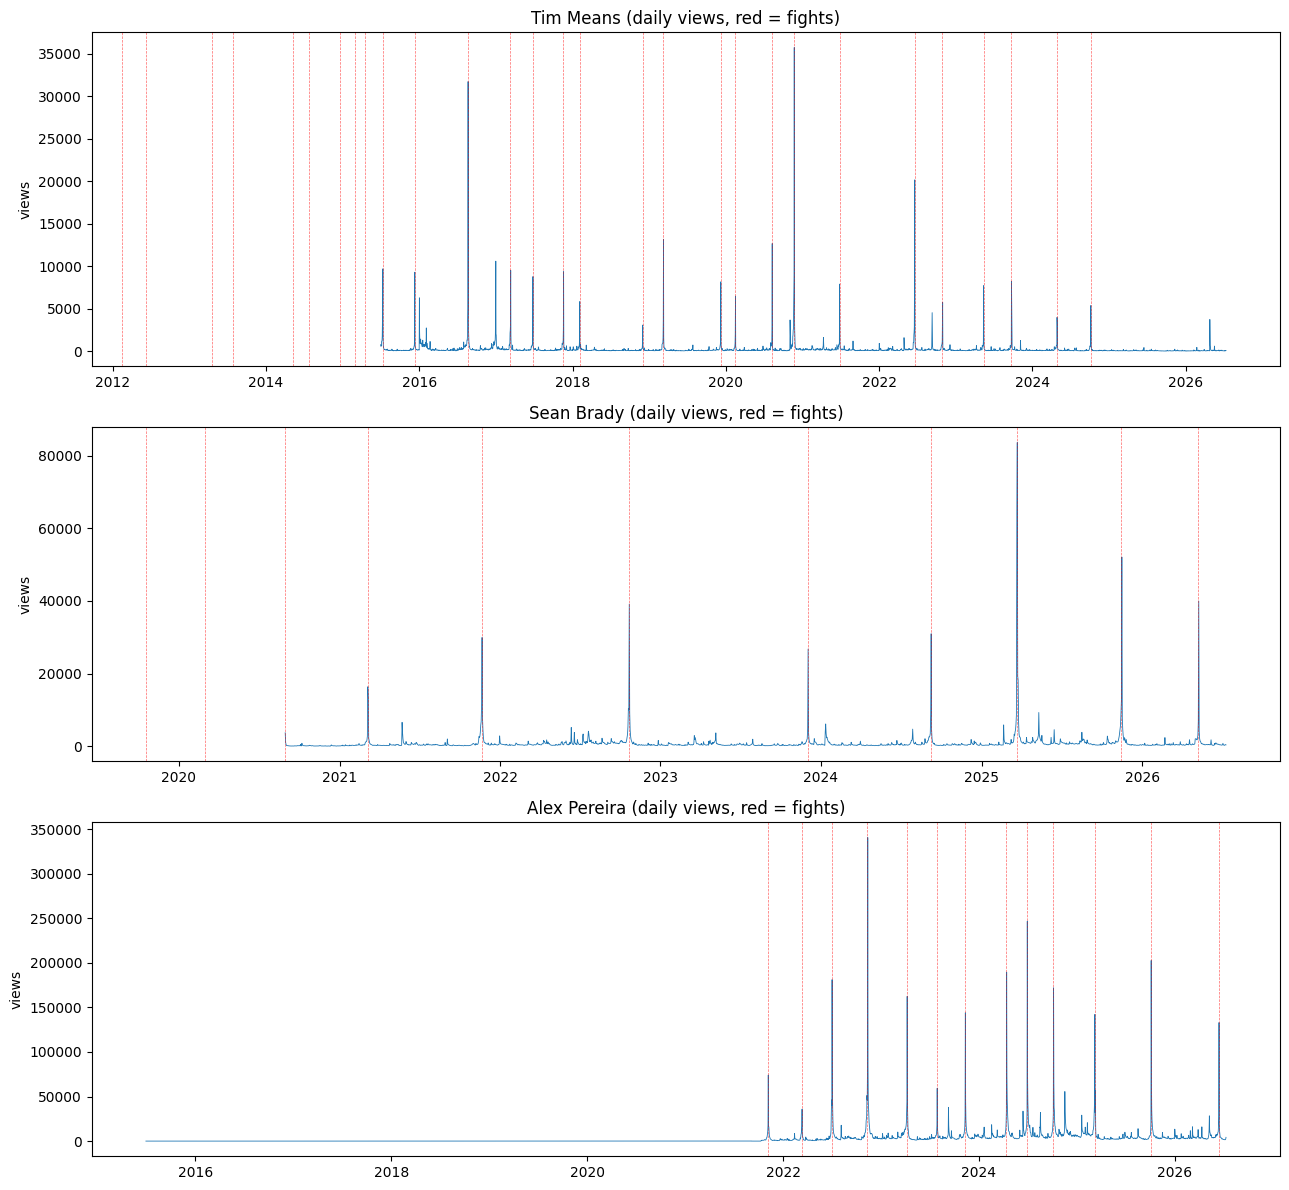

In [ ]:
# BLOCK 16: plot daily pageviews against fight dates

import matplotlib.pyplot as plt

# fight dates, active universe only
fights = pd.read_parquet(OUTPUT_DIR / 'fights_per_fighter.parquet')[['FIGHTER', 'DATE_PARSED']]
fights['DATE_PARSED'] = pd.to_datetime(fights['DATE_PARSED'], errors='coerce')
fights = fights[fights['FIGHTER'].isin(active['FIGHTER'])].dropna(subset=['DATE_PARSED'])

pv = pd.read_parquet(PV_PATH)
pv['date'] = pd.to_datetime(pv['date'], format='%Y%m%d')

# veteran, modern regular, star: spans the eras and shows baseline vs spike-only profiles
PLOT_FIGHTERS = ['Tim Means', 'Sean Brady', 'Alex Pereira']

fig, axes = plt.subplots(len(PLOT_FIGHTERS), 1, figsize=(13, 4 * len(PLOT_FIGHTERS)), squeeze=False)
for ax, name in zip(axes[:, 0], PLOT_FIGHTERS):
    s = pv[pv['FIGHTER'] == name].sort_values('date')
    ax.plot(s['date'], s['views'], linewidth=0.6)
    for d in fights.loc[fights['FIGHTER'] == name, 'DATE_PARSED']:
        ax.axvline(d, color='red', linestyle='--', linewidth=0.5, alpha=0.6)
    ax.set_title(f'{name} (daily views, red = fights)')
    ax.set_ylabel('views')
plt.tight_layout()
plt.show()

### Baseline and activation features

The daily pageview series splits into the two signals the axis needs: a baseline, the sustained between-fights interest that stands for brand, and an activation, the spike a fight generates, that stands for event-driven attention. The plots motivate the split directly; a star like Pereira shows a raised floor between fights plus spikes on top, while a mid-tier fighter shows spikes on a near-zero floor, so the two are separable and a single number would conflate them.

Window widths are read off the spike shapes, which were tight across eras: a fight window of 7 days before to 14 days after the bout, asymmetric because the pre-fight rise is short and the post-fight decay runs a little longer. Era-varying widths were considered, on the theory that the denser modern calendar compresses promotion, but the individual spikes looked similarly tight in 2016 and 2025, so a fixed window is used and the era effects are left to the normalisation step rather than the window geometry.

Baseline is the median of daily views on non-fight-window days over the trailing 365 days to the freeze date. Median rather than mean because the floor is itself choppy and a mean would let stray mini-spikes leak activation back into the baseline; trailing-365 rather than all-history because the axis measures current sustained profile, so a fighter big three years ago but quiet now should read low now.

Activation is measured per fight as the mean views in the fight window minus the fighter's baseline, a lift rather than a level, so it captures how much a fight moved them rather than how big they already are. Two summaries are kept: average activation across a fighter's fights (the standard feature, the typical bump, stable) and peak activation (the single biggest fight-window day, raw views, retained as a secondary because one viral night carries real commercial meaning even as an outlier). The gap between them is itself informative.

Two boundaries are deliberate. Fights before the mid-2015 pageview floor have no data behind them and are skipped, not counted as zero. And activation is fight-windowed by construction, so attention spikes that are not aligned to a fight (a viral clip, a callout, an incident) are not captured here; this is a defensible scope choice for a fight-value axis, noted for the limitations rather than chased.

In [ ]:
# BLOCK 17: baseline and activation features from daily pageviews

PRE, POST     = 7, 14       # fight window: days before, after
BASE_DAYS     = 365         # trailing baseline lookback
RELIABLE_DAYS = 548         # 18 months of history for a settled baseline

pv = pd.read_parquet(PV_PATH)
pv['date'] = pd.to_datetime(pv['date'], format='%Y%m%d')
pv_min, pv_max = pv['date'].min(), pv['date'].max()
has_series = set(pv['FIGHTER'])      # appears here = has an article

fights = pd.read_parquet(OUTPUT_DIR / 'fights_per_fighter.parquet')[['FIGHTER', 'DATE_PARSED']]
fights['DATE_PARSED'] = pd.to_datetime(fights['DATE_PARSED'], errors='coerce')
fights = fights.dropna(subset=['DATE_PARSED'])
fdates_by = fights.groupby('FIGHTER')['DATE_PARSED'].apply(list)

def fighter_features(name, series, fdates):
    s = series.set_index('date')['views'].sort_index()

    # under 18 months of history, so the baseline may still carry the early article traffic
    first_pv = s.index.min() if len(s) else ANALYSIS_DATE
    reliable = (ANALYSIS_DATE - first_pv).days >= RELIABLE_DAYS

    # fight windows within the global pageview range
    windows = []
    for d in fdates:
        lo, hi = d - pd.Timedelta(days=PRE), d + pd.Timedelta(days=POST)
        if hi < pv_min or lo > pv_max:
            continue
        windows.append((lo, hi))

    base_lo = ANALYSIS_DATE - pd.Timedelta(days=BASE_DAYS)
    in_window = pd.Series(False, index=s.index)
    for lo, hi in windows:
        in_window |= (s.index >= lo) & (s.index <= hi)
    base_days = s[(s.index >= base_lo) & ~in_window]
    baseline  = base_days.median() if len(base_days) else 0.0

    lifts, peaks = [], []
    for lo, hi in windows:
        w = s[(s.index >= lo) & (s.index <= hi)]
        if not len(w):              # window predates this fighter's article, or a data gap
            continue
        lifts.append(w.mean() - baseline)
        peaks.append(w.max())

    return {
        'FIGHTER':           name,
        'pv_baseline':       baseline,
        'pv_activation':     (sum(lifts) / len(lifts)) if lifts else 0.0,
        'pv_peak':           max(peaks) if peaks else 0.0,
        'n_fight_windows':   len(lifts),
        'baseline_reliable': reliable,
    }

feat_rows = [fighter_features(name, s, fdates_by.get(name, []))
             for name, s in pv.groupby('FIGHTER')]
feats = pd.DataFrame(feat_rows)

# no-article fighters: explicit true zeros
zeros = pd.read_parquet(OUTPUT_DIR / 'pageview_title_map.parquet')
zeros = zeros[zeros['status'] == 'zero']['FIGHTER']
zero_rows = pd.DataFrame({'FIGHTER': zeros, 'pv_baseline': 0.0, 'pv_activation': 0.0,
                          'pv_peak': 0.0, 'n_fight_windows': 0, 'baseline_reliable': False})
feats = pd.concat([feats, zero_rows], ignore_index=True)

# unmeasurable = has an article but no fight landed in its pageview span
# (debutants whose article postdates their fights, long-dormant returnees, data gaps); distinct from a no-article zero
feats['activation_measurable'] = ~((feats['n_fight_windows'] == 0) & feats['FIGHTER'].isin(has_series))

feats.to_parquet(OUTPUT_DIR / 'pageview_features.parquet', index=False)

print(f'features for {len(feats)} fighters (incl {len(zero_rows)} no-article zeros)')
print(f'baseline unreliable (<18mo history): {(~feats["baseline_reliable"]).sum()}')
print(f'activation unmeasurable (article postdates fights / dormant / gap): {(~feats["activation_measurable"]).sum()}')
neg = feats['pv_activation'] < 0
print(f'negative activations: {neg.sum()} (legitimate where baseline_reliable)')
print(feats[['pv_baseline','pv_activation','pv_peak']].describe().round(0))

features for 512 fighters (incl 18 no-article zeros)
baseline unreliable (<18mo history): 67
activation unmeasurable (article postdates fights / dormant / gap): 11
negative activations: 3 (legitimate where baseline_reliable)
       pv_baseline  pv_activation   pv_peak
count        512.0          512.0     512.0
mean         297.0         2442.0   57313.0
std          620.0         4230.0   86674.0
min            0.0          -36.0       0.0
25%           36.0          546.0   10606.0
50%           98.0         1086.0   24346.0
75%          272.0         2695.0   64351.0
max         5797.0        59682.0  655946.0


### Pageview findings

The active universe fighters carry three pageview features: baseline (sustained floor), activation (average fight-window lift above baseline), peak (single biggest fight-window day).

Analysing the representative examples from the plot of daily pageviews against fight dates, there is a heavy right-skew, the expected shape for a fame distribution: most fighters modest, a long tail of stars.

The data shows separable baseline and activation; stars carry a raised floor with spikes on top, while mid-level fighters show spikes on a near-zero floor. That separation is the whole point of the split, and the plots confirm it: a single combined number would have conflated the sustained level with the event bump.

Two reliability flags travel alongside the values without altering them. baseline_reliable marks the 67 fighters with under 18 months of pageview history, where the floor is still carrying the article-creation surge and the baseline-activation split is therefore provisional. activation_measurable marks the 11 fighters who have an article but no fight falling inside their pageview span (recent debutants whose page postdates their bouts, long-dormant returnees, and the occasional data gap); for these, activation is absent rather than zero.

That distinction matters and is kept deliberate. The 18 no-article fighters are true zeros, a genuine low-profile reading, while the 11 unmeasurable fighters are missing data behind an article that exists. Treating the two the same would be wrong, so they are held apart throughout.

A further 3 activations come out negative. These are mostly legitimate: established fighters whose recent fights drew at or below their normal floor, which is a real profile rather than an error, so the values are kept as they are.

The coverage cost is worth stating plainly. Around 29 of the 791 fighters (roughly 4%) have an activation signal that is either a true zero or unmeasurable, and these concentrate among newer and lower-profile fighters. This is the same English-language Wikipedia coverage gap seen at the resolution stage, now showing up in the activation feature, and it is flagged for the limitations.

Both flags are carried forward into normalisation and the composite, so provisional baselines and unmeasurable activations can be handled with appropriate caution rather than treated as ordinary values.

## Section 4: GDELT news attention

GDELT indexes global online news coverage, so this signal measures media attention rather than fan lookup behaviour: how much the sport's press writes about a fighter, distinct from how much fans search for them on Wikipedia.

The feature is news-coverage volume: the count of person-mentions matching each fighter across a twelve-month window, with the number of distinct days they appear kept alongside. Volume is a strong, wide-ranging signal; a pilot found the two fighters furthest apart in profile separated by nearly two orders of magnitude, a spread comparable to the pageview features. Source diversity was considered as an alternative feature but dropped: even the clearest crossover name in the roster is covered mostly by MMA-specific outlets, so a diversity measure would be near-zero for almost everyone and would not discriminate across the population.

The data is acquired from the GDELT public dataset in BigQuery rather than the document API, which rate-limited to unusable coverage at roster scale. The query matches each fighter by splitting the tagged-persons field, lowercasing, and joining exactly against the roster; this clears the query engine's cost limit and tightens matching. Names are matched on the full name rather than the surname to reduce collisions, and a small set of confirmed same-name collisions with more famous non-fighters is nulled by hand. The acquisition query and the roster it uses are recorded for reproducibility.

The BigQuery query matches fighters by name, so it needs the active universe as a SQL array of lowercased names. This generates that array from the active universe for pasting into the query.

In [ ]:
# BLOCK 18: "ROSTER" for GDELT BigQuery

active = pd.read_parquet(OUTPUT_DIR / 'active_universe.parquet')[['FIGHTER']].copy()
names = active['FIGHTER'].dropna().unique().tolist()

# lowercase for the case insensitive match; escape single quotes for SQL
def sql_escape(n):
    return n.lower().replace("'", "''")

array_items = ",\n    ".join(f"'{sql_escape(n)}'" for n in names)
print(f"generated {len(names)} names")
print("--- copy from here ---")
print(f"WITH roster AS (\n  SELECT name AS fighter\n  FROM UNNEST([\n    {array_items}\n  ]) AS name\n)")

generated 791 names
--- copy from here ---
WITH roster AS (
  SELECT name AS fighter
  FROM UNNEST([
    'jon jones',
    'islam makhachev',
    'ciryl gane',
    'shavkat rakhmonov',
    'ilia topuria',
    'alexander volkanovski',
    'khamzat chimaev',
    'dricus du plessis',
    'michael morales',
    'kamaru usman',
    'alex pereira',
    'merab dvalishvili',
    'stipe miocic',
    'justin gaethje',
    'carlos prates',
    'max holloway',
    'tom aspinall',
    'arman tsarukyan',
    'aljamain sterling',
    'charles oliveira',
    'movsar evloev',
    'alexander volkov',
    'umar nurmagomedov',
    'sean brady',
    'yaroslav amosov',
    'petr yan',
    'ian machado garry',
    'nassourdine imavov',
    'sean strickland',
    'magomed ankalaev',
    'diego lopes',
    'josh hokit',
    'carlos ulberg',
    'sergei pavlovich',
    'jiri prochazka',
    'robert whittaker',
    'jack della maddalena',
    'sean o''malley',
    'valentina shevchenko',
    'paddy pimblett',
   

## Section 5: Career signals (booking-model target)

In [ ]:
# BLOCK 19: load GDELT volume, reconcile a duplicate, null confirmed namesakes

gdelt = pd.read_csv(OUTPUT_DIR / 'gdelt_volume.csv')
print(f'loaded {len(gdelt)} fighters')

# the query roster carried both spellings of one fighter; keep the correct one,
# sum the two rows in case coverage split across them
DUP_WRONG, DUP_RIGHT = 'rafael cerquiera', 'rafael cerqueira'
if DUP_WRONG in gdelt['fighter'].values:
    wrong = gdelt[gdelt['fighter'] == DUP_WRONG]
    gdelt.loc[gdelt['fighter'] == DUP_RIGHT, 'gdelt_volume'] += int(wrong['gdelt_volume'].iloc[0])
    gdelt = gdelt[gdelt['fighter'] != DUP_WRONG].reset_index(drop=True)
    print(f'merged {DUP_WRONG} into {DUP_RIGHT}')

# confirmed name collisions with more famous non-fighters; extend after checking the ranking
# nulled (not zeroed) so the composite reads them as missing, not as genuine low coverage
NAMESAKE_FLAGS = [
    'victor hugo',       # the author
    'michael johnson',   # common name, multiple public figures
    'mike davis',        # common name, multiple public figures
]
mask = gdelt['fighter'].isin(NAMESAKE_FLAGS)
gdelt.loc[mask, ['gdelt_volume', 'gdelt_active_days']] = np.nan
print(f'nulled {mask.sum()} namesake-flagged fighters')

# match to canonical keys on normalised name (lowercase, single apostrophe)

active = pd.read_parquet(OUTPUT_DIR / 'active_universe.parquet')

def norm(s):
    # lowercase and collapse the doubled apostrophes from the SQL escaping
    return s.lower().replace("''", "'").strip()

# lookup from normalised canonical name -> actual canonical key
canon_lookup = {norm(k): k for k in active['FIGHTER']}

# map each GDELT fighter (already lowercase) to its canonical key
gdelt['FIGHTER'] = gdelt['fighter'].apply(lambda x: canon_lookup.get(norm(x)))

# report anything still unmatched
unmatched = gdelt[gdelt['FIGHTER'].isna()]
print(f'{gdelt["FIGHTER"].notna().sum()} matched, {len(unmatched)} still unmatched')
if len(unmatched):
    print(unmatched['fighter'].tolist())

gdelt = gdelt[['FIGHTER', 'gdelt_volume', 'gdelt_active_days']]

# GDELT entity-extraction failures. GDELT's person tagger drops or fragments a set of
# high-profile fighters (Du Plessis scattered across "plessis v strickland" fragments;
# Leon Edwards lost while a namesake inflates an obscure "christian edwards"), so they
# return a false 0 that no name-matching can recover, because the tag was never written.
# A genuine zero and a failed lookup are identical in the raw count, so an independent
# signal separates them: zero GDELT while fight week pageview attention is top-quartile
# is an extraction failure, not real silence. Nulled (not zeroed) so the composite drops
# GDELT for them and scores them on their three other signals, which are strong for
# exactly these fighters.
pv_act = pd.read_parquet(OUTPUT_DIR / 'pageview_features.parquet')[['FIGHTER', 'pv_activation']]
gdelt = gdelt.merge(pv_act, on='FIGHTER', how='left')
act_thresh = gdelt['pv_activation'].quantile(0.75)
extraction_fail = (gdelt['gdelt_volume'].fillna(0) <= 0) & (gdelt['pv_activation'] >= act_thresh)
print(f'GDELT extraction failures nulled (0 volume, top-quartile attention): {int(extraction_fail.sum())}')
print(sorted(gdelt.loc[extraction_fail, 'FIGHTER'].tolist()))
gdelt.loc[extraction_fail, ['gdelt_volume', 'gdelt_active_days']] = np.nan
gdelt = gdelt.drop(columns='pv_activation')

print(f'\nfinal: {len(gdelt)} fighters, {gdelt["gdelt_volume"].notna().sum()} with a volume')
print(gdelt.sort_values('gdelt_volume', ascending=False).head(10).to_string(index=False))
gdelt.to_parquet(OUTPUT_DIR / 'gdelt_volume.parquet', index=False)

loaded 791 fighters
merged rafael cerquiera into rafael cerqueira
nulled 3 namesake-flagged fighters
790 matched, 0 still unmatched
GDELT extraction failures nulled (0 volume, top-quartile attention): 9
['Benoit Saint Denis', 'Carlos Prates', 'Kai Kara-France', 'Michael Johnson', 'Mickey Gall', 'Ovince Saint Preux', 'Patchy Mix', 'Rafael Dos Anjos', 'Said Nurmagomedov']

final: 790 fighters, 779 with a volume
        FIGHTER  gdelt_volume  gdelt_active_days
   Ilia Topuria        3700.0              345.0
 Justin Gaethje        3588.0              331.0
   Alex Pereira        2898.0              333.0
 Conor McGregor        2663.0              351.0
     Ciryl Gane        2052.0              287.0
   Max Holloway        1998.0              321.0
Khamzat Chimaev        1905.0              314.0
Islam Makhachev        1817.0              330.0
      Jon Jones        1715.0              332.0
 Dustin Poirier        1674.0              299.0


### GDELT Findings

The ranking is led by the sport's most-covered names, which matches expectation and confirms the name matching is working. The roster carried one fighter under two spellings, merged here into a single row. A small set of confirmed name collisions with more famous non-fighters is nulled rather than zeroed, so the composite reads them as missing rather than as genuine low coverage; this list is provisional and extends on review of the full ranking. The remaining fighters all resolve to canonical keys, so the feature joins cleanly to the rest of the axis.

In [ ]:
# BLOCK 20: career signals, main event rate (booking model target)

fpf = pd.read_parquet(OUTPUT_DIR / 'fights_per_fighter.parquet')
print(f'{len(fpf)} fighter-fight rows, {fpf["FIGHTER"].nunique()} fighters')

# card position within each event; row order is card order, main event first.
# each bout is two rows (both fighters), so position is per FIGHT_ID, not per row
event_order = (
    fpf[['EVENT', 'FIGHT_ID']].drop_duplicates()
    .assign(card_pos=lambda d: d.groupby('EVENT', sort=False).cumcount())
)
fpf = fpf.merge(event_order, on=['EVENT', 'FIGHT_ID'], how='left')
fpf['is_main'] = fpf['card_pos'] == 0

career = fpf.groupby('FIGHTER').agg(
    total_fights=('FIGHT_ID', 'nunique'),
    main_events=('is_main', 'sum'),
).reset_index()

# share of a fighter's fights that were the main event; the institutional-endorsement signal
career['main_event_rate'] = career['main_events'] / career['total_fights']

# reliability flag: a rate from fewer than 3 fights is thin, tagged not dropped,
# consistent with the reliability tiers used on the other signals
career['career_reliable'] = career['total_fights'] >= 3

print(f'\ncareer signals for {len(career)} fighters')
print(f"reliable (3+ fights): {career['career_reliable'].sum()}")
print('\ntop 10 by main-event rate:')
print(career.sort_values(['main_event_rate', 'total_fights'], ascending=[False, False])
      [['FIGHTER', 'total_fights', 'main_events', 'main_event_rate', 'career_reliable']]
      .head(10).to_string(index=False))

career.to_parquet(OUTPUT_DIR / 'career_signals.parquet', index=False)
print('\nsaved career_signals.parquet')

17358 fighter-fight rows, 2710 fighters

career signals for 2710 fighters
reliable (3+ fights): 1860

top 10 by main-event rate:
        FIGHTER  total_fights  main_events  main_event_rate  career_reliable
     Bas Rutten             2            2         1.000000            False
  Igor Zinoviev             1            1         1.000000            False
     John Lober             1            1         1.000000            False
 Chan Sung Jung            12           10         0.833333             True
 Conor McGregor            15           12         0.800000             True
 Frank Shamrock             5            4         0.800000             True
Israel Adesanya            19           15         0.789474             True
      Jon Jones            23           18         0.782609             True
 Anderson Silva            24           18         0.750000             True
  Randy Couture            24           18         0.750000             True

saved career_signals.pa

### Career signal findings

Main event rate is computed here as the target for the booking propensity model, not as a public profile signal. It is the share of a fighter's bouts that headlined a card; headlining measures institutional endorsement and drawing power, which is what the booking model predicts from the two merit axes.

Main event rate rather than title fight rate is used, for two reasons. A title fight is partly a measure of competitive merit, which belongs on the competitive axis, whereas a fighter can headline a non title card on draw alone. The source's title flag also marks reality show tournament finals as title bouts, which are not championship fights, so a title rate would carry contamination that main event rate avoids.

A rate computed from very few fights is unstable, so fighters below three fights are flagged rather than dropped, the same reliability discipline applied to the other signals. The flag travels with the value. The top of the ranking is genuine repeat-headliners; the perfect rates below the reliability threshold are single fight fighters, correctly tagged unreliable.

Main event rate is deliberately kept off the public profile axis ; it is retained for display and as the booking model target.

### Testing for a recency bias

The proposal specified era aware normalisation. Before applying it, this checks whether a bias actually exists: do fighters who fought more recently score higher on the attention signals simply for being current, independent of drawing power. The signals are measured over a common recent window, so the fighters are largely contemporaneous already; this quantifies any residual association between signal strength and how recently a fighter last competed.

In [ ]:
# BLOCK 21:

# does signal strength correlate with recency? if not, era-normalisation isn't needed

pv   = pd.read_parquet(OUTPUT_DIR / 'pageview_features.parquet')
gd   = pd.read_parquet(OUTPUT_DIR / 'gdelt_volume.parquet')
fpf  = pd.read_parquet(OUTPUT_DIR / 'fights_per_fighter.parquet')
active = pd.read_parquet(OUTPUT_DIR / 'active_universe.parquet')

# recency proxy: each fighter's last-fight date
last_fight = fpf.groupby('FIGHTER')['DATE_PARSED'].max().reset_index(name='last_fight')

df = (active[['FIGHTER']]
      .merge(pv[['FIGHTER','pv_baseline']], on='FIGHTER', how='left')
      .merge(gd[['FIGHTER','gdelt_volume']], on='FIGHTER', how='left')
      .merge(last_fight, on='FIGHTER', how='left'))
df['recency'] = pd.to_datetime(df['last_fight']).astype('int64')  # ordinal for correlation

for sig in ['pv_baseline', 'gdelt_volume']:
    sub = df[[sig, 'recency']].dropna()
    rho, p = spearmanr(sub[sig], sub['recency'])
    print(f'{sig} vs recency: rho = {rho:.3f} (p = {p:.3g}, n={len(sub)})')

pv_baseline vs recency: rho = 0.240 (p = 5.1e-08, n=503)
gdelt_volume vs recency: rho = 0.270 (p = 1.6e-14, n=779)


### Recency Findings

The association between signal strength and recency is statistically clear but small, explaining only a few percent of the variation in each signal. Combined with the post-PPV era being too young to form its own normalisation group, this does not justify the two bucket scheme the proposal specified. Signals are z-scored across all fighters instead, and the small residual recency lift is recorded as a limitation. The reasoning is set out in full in the deviation log.

## Section 6: Public profile axis composite

The three attention signals are combined into a single public profile score: the pageview baseline, pageview activation, and GDELT news volume. Each is z-scored and the available signals are averaged per fighter. Main event rate is computed alongside these (see the previous block) but is deliberately excluded from the composite: headlining is a promoter decision rather than a direct measure of public attention, and it is circular for the booking use case the axis feeds, so it is retained as a display column and as the booking-model target rather than scored into the axis.

A true zero and a missing value are treated differently. A genuine zero (no Wikipedia article, or no news coverage) is a real low profile reading and is kept, contributing a low z-score. A missing value (a nulled GDELT namesake, or an activation that could not be measured) is dropped from that fighter's average rather than counted as zero; a fighter is scored on whatever signals are available for them. Missing values fall mostly among lower profile fighters who score low regardless, so the composite is not sensitive to how they are handled.

The signals (pageviews, GDELT volume) are heavily right skewed, so they are log-transformed before z-scoring to stop a few very large values dominating; main-event rate is a bounded rate and is not transformed.

Signals are z-scored across all fighters rather than within era buckets. The proposal specified two-bucket era normalisation, but the post-PPV era is only months old and too sparse to form a normalisation group, and an empirical check found the recency association in the signals to be real but small (Spearman rho of 0.20 for pageview baseline and 0.23 for GDELT volume). Straight z-scoring is used, with the small residual recency bias noted as a limitation.

In [ ]:
# BLOCK 22: public profile axis composite

pv     = pd.read_parquet(OUTPUT_DIR / 'pageview_features.parquet')
gd     = pd.read_parquet(OUTPUT_DIR / 'gdelt_volume.parquet')
career = pd.read_parquet(OUTPUT_DIR / 'career_signals.parquet')
active = pd.read_parquet(OUTPUT_DIR / 'active_universe.parquet')

# assemble the attention signals on the active universe. main event rate is loaded but carried
# as a non composite column, not scored into the axis ; it is kept for display
# and as the booking model target.
df = (active[['FIGHTER']]
      .merge(pv[['FIGHTER', 'pv_baseline', 'pv_activation']], on='FIGHTER', how='left')
      .merge(gd[['FIGHTER', 'gdelt_volume']], on='FIGHTER', how='left')
      .merge(career[['FIGHTER', 'main_event_rate']], on='FIGHTER', how='left'))

# unmeasurable activation is stored as 0 but means "could not measure", not "real zero";
# null it so it drops from the fighter's average. fighters absent from the pageview features
# have no flag (NaN); treat those as not measurable too.
df = df.merge(pv[['FIGHTER', 'activation_measurable']], on='FIGHTER', how='left')
measurable = df['activation_measurable'].fillna(False).astype(bool)
df.loc[~measurable, 'pv_activation'] = np.nan

# the composite rests on the attention signals only; all three are right skewed counts and are
# log-transformed before z-scoring.
SIGNALS     = ['pv_baseline', 'pv_activation', 'gdelt_volume']
LOG_SIGNALS = ['pv_baseline', 'pv_activation', 'gdelt_volume']

# verify the zero-vs-missing distinction survived the inputs: a genuine zero must be 0,
# an unmeasurable/nulled value must be NaN.
print('zero vs missing per signal (0 = real low, NaN = dropped from average):')
for s in SIGNALS:
    print(f"  {s:16} zeros={ (df[s] == 0).sum():4}   missing={df[s].isna().sum():4}")

# log-transform the skewed count signals (log1p keeps a true zero at zero); log1p on NaN
# yields NaN, silence the warning
with np.errstate(invalid='ignore'):
    for s in LOG_SIGNALS:
        df[s + '_t'] = np.log1p(df[s])

# z-score each signal across all fighters, ignoring NaN (missing stays NaN, not imputed)
TCOLS = [s + '_t' for s in SIGNALS]
for c in TCOLS:
    mu, sd = df[c].mean(), df[c].std()
    df[c + '_z'] = (df[c] - mu) / sd

# composite = mean of a fighter's available (non-NaN) z-scores
ZCOLS = [c + '_z' for c in TCOLS]
df['public_profile'] = df[ZCOLS].mean(axis=1, skipna=True)
df['n_signals'] = df[ZCOLS].notna().sum(axis=1)   # how many of the three z-scores each score rests on

# source count reliability: the axis rests on two independent sources, Wikipedia (which produces
# both pageview signals) and GDELT. a fighter scored on only one carries a thinner reading and is
# tagged, not dropped, consistent with the competitive axis reliability tiers. removing main-event
# rate leaves the deep-roster fighters who previously reached two signals on {gdelt, main_event=0}
# resting on GDELT alone; the tag surfaces that rather than hiding them from the map.
wiki_present  = df['pv_baseline_t_z'].notna() | df['pv_activation_t_z'].notna()
gdelt_present = df['gdelt_volume_t_z'].notna()
df['source_count'] = wiki_present.astype(int) + gdelt_present.astype(int)
df['profile_reliability'] = np.select(
    [df['source_count'] >= 2, df['source_count'] == 1],
    ['multi_source', 'single_source'],
    default='none')

# main-event rate previously guaranteed a score for anyone with a fight; without it a fighter
# with neither source can no longer be placed. report them; they are excluded, not scored on nothing.
excluded = df[df['n_signals'] == 0]
print(f"\nscored {df['public_profile'].notna().sum()} fighters; "
      f"{(df['profile_reliability'] == 'single_source').sum()} single-source, "
      f"{len(excluded)} with no usable signal (excluded)")
if len(excluded):
    print('excluded (no Wikipedia and no GDELT):', excluded['FIGHTER'].tolist())

print('\ntop 15 public profile:')
print(df.sort_values('public_profile', ascending=False)
      [['FIGHTER', 'public_profile', 'n_signals', 'profile_reliability']].head(15).to_string(index=False))

# carry main_event_rate as a non-composite column for the booking model and dashboard display
out = df[['FIGHTER', 'public_profile', 'n_signals', 'source_count', 'profile_reliability']
         + SIGNALS + ['main_event_rate']]
out.to_parquet(OUTPUT_DIR / 'public_profile_axis.parquet', index=False)
print('\nsaved public_profile_axis.parquet')

zero vs missing per signal (0 = real low, NaN = dropped from average):
  pv_baseline      zeros=  20   missing= 288
  pv_activation    zeros=  18   missing= 299
  gdelt_volume     zeros=  72   missing=  12

scored 791 fighters; 300 single-source, 0 with no usable signal (excluded)

top 15 public profile:
              FIGHTER  public_profile  n_signals profile_reliability
       Conor McGregor        2.361418          3        multi_source
         Ilia Topuria        2.148090          3        multi_source
            Jon Jones        2.112251          3        multi_source
         Alex Pereira        2.033452          3        multi_source
      Khamzat Chimaev        1.984641          3        multi_source
       Justin Gaethje        1.951409          3        multi_source
      Islam Makhachev        1.933991          3        multi_source
         Max Holloway        1.810544          3        multi_source
       Dustin Poirier        1.770233          3        multi_source
    

/tmp/ipykernel_1336/1247140693.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  measurable = df['activation_measurable'].fillna(False).astype(bool)


## Conclusion

The public profile axis scores 791 active fighters on a single latent measure of drawing power, inferred from three attention signals: the Wikipedia pageview baseline (a fighter's sustained profile), the pageview activation (the lift around a fight), and GDELT news-mention volume. Each signal is z-scored, the count-based signals are log-transformed first to control their right skew, and each fighter is scored on whatever signals are available for them; genuine zeros are kept as real low profile readings while unmeasurable values are dropped from the average rather than counted as zero.

Wikipedia resolution reached 62% of the roster, with the remaining fighters overwhelmingly having no English language article; these fall back to single source GDELT scoring rather than being dropped, which accounts for the 300 single source fighters. A source count reliability flag records whether each score rests on both sources or one, so downstream use can weight a single source reading accordingly. All 791 fighters carry a usable signal; none is excluded.

The ranking behaves as expected, led by the sport's most-covered names, which confirms the signals and the name matching are working. Two design decisions are recorded as scoped limitations: era-bucketed normalisation was dropped because the post-PPV era is too young to form a normalisation group and the recency association in the signals proved real but small, so straight z-scoring is used with the residual recency lift noted; and main event rate, though computed here, is deliberately kept off the axis as a promoter decision variable, retained instead as the target for the booking-propensity model.

The axis output (`public_profile_axis.parquet`) pairs with the competitive rating to form the value map, and supplies the profile side of the booking model in the next notebook.